In [1]:
!pip install torch

Chargement du fichier...


/tmp/ipykernel_5341/879923858.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df.resample('H', on='Date_Heure').size().reset_index(name='nombre_voitures')


✅ Données préparées : 17542 heures
Période : de 2023-01-01 01:00:00 à 2024-12-31 22:00:00

Aperçu :
                     nombre_voitures
Date_Heure                          
2023-01-01 01:00:00                2
2023-01-01 02:00:00                0
2023-01-01 03:00:00                0
2023-01-01 04:00:00                0
2023-01-01 05:00:00                1
2023-01-01 06:00:00                7
2023-01-01 07:00:00               13
2023-01-01 08:00:00               17
2023-01-01 09:00:00               13
2023-01-01 10:00:00               17

Forme des données :
X_train : torch.Size([13899, 168, 1]) | y_train : torch.Size([13899, 1])

Entraînement du modèle LSTM...
Epoch 1/25 - Loss: 0.019826
Epoch 5/25 - Loss: 0.004623
Epoch 10/25 - Loss: 0.004353
Epoch 15/25 - Loss: 0.004207
Epoch 20/25 - Loss: 0.004199
Epoch 25/25 - Loss: 0.004143

✅ Résultats sur le test :
MAE  : 2.98 voitures par heure
RMSE : 4.15 voitures par heure


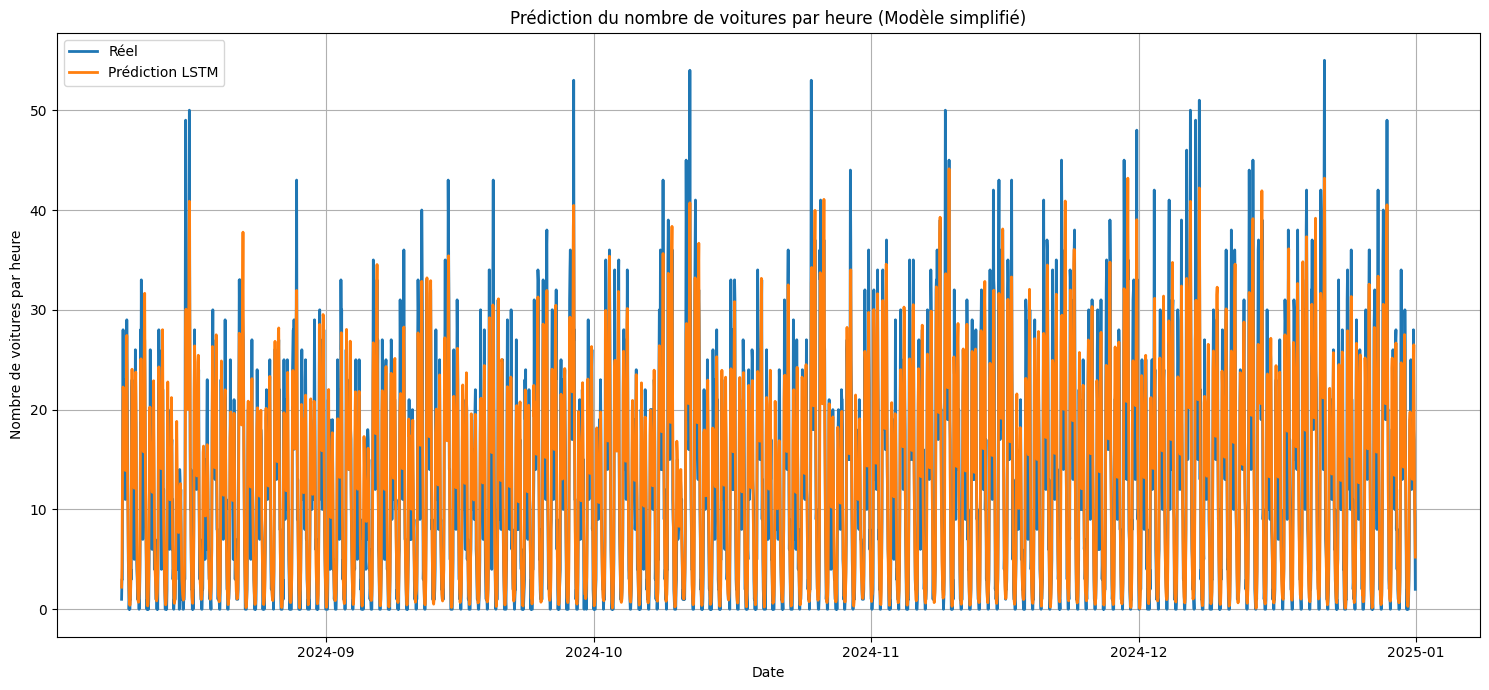


Modèle sauvegardé !


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ====================== 1. CHARGEMENT ET NETTOYAGE ======================
print("Chargement du fichier...")
df = pd.read_csv('donnees_synthetiques_tollxpress_benin_2023-2024.csv')

# On ne garde QUE la colonne Date_Heure
df = df[['Date_Heure']].copy()

# Conversion en datetime
df['Date_Heure'] = pd.to_datetime(df['Date_Heure'])

# Création du nombre de voitures par heure (comptage des passages)
hourly = df.resample('H', on='Date_Heure').size().reset_index(name='nombre_voitures')

# On met la date comme index
hourly.set_index('Date_Heure', inplace=True)

print(f"✅ Données préparées : {len(hourly)} heures")
print(f"Période : de {hourly.index.min()} à {hourly.index.max()}")
print("\nAperçu :")
print(hourly.head(10))

values = hourly['nombre_voitures'].values.reshape(-1, 1)

# Normalisation entre 0 et 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(values)

# Paramètres
lookback = 168          # 7 jours d'historique (recommandé)
train_ratio = 0.8

# Création des séquences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, lookback)

# Split train/test
train_size = int(len(X) * train_ratio)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversion en tenseurs PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"\nForme des données :")
print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")

# ====================== 3. Dataset & Model (identique) ======================
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ====================== 4. Entraînement ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\nEntraînement du modèle LSTM...")
epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.6f}")

# ====================== 5. Évaluation & Graphique ======================
model.eval()
predictions = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        pred = model(batch_x).cpu().numpy()
        predictions.append(pred)

predictions = np.concatenate(predictions)
predictions = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.numpy())

# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test_real, predictions)
rmse = np.sqrt(mean_squared_error(y_test_real, predictions))

print(f"\n✅ Résultats sur le test :")
print(f"MAE  : {mae:.2f} voitures par heure")
print(f"RMSE : {rmse:.2f} voitures par heure")

# Graphique
plt.figure(figsize=(15, 7))
plt.plot(hourly.index[-len(y_test_real):], y_test_real, label="Réel", linewidth=2)
plt.plot(hourly.index[-len(predictions):], predictions, label="Prédiction LSTM", linewidth=2)
plt.title("Prédiction du nombre de voitures par heure (Modèle simplifié)")
plt.xlabel("Date")
plt.ylabel("Nombre de voitures par heure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Sauvegarde
torch.save(model.state_dict(), "lstm_voitures_par_heure_simplifie.pth")
print("\nModèle sauvegardé !")

✅ Modèle LSTM chargé avec succès.
Génération des prédictions pour les 168 prochaines heures...
✅ Prédictions générées : 168 points.


/tmp/ipykernel_5341/2056598662.py:68: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=num_future_steps, freq='H')


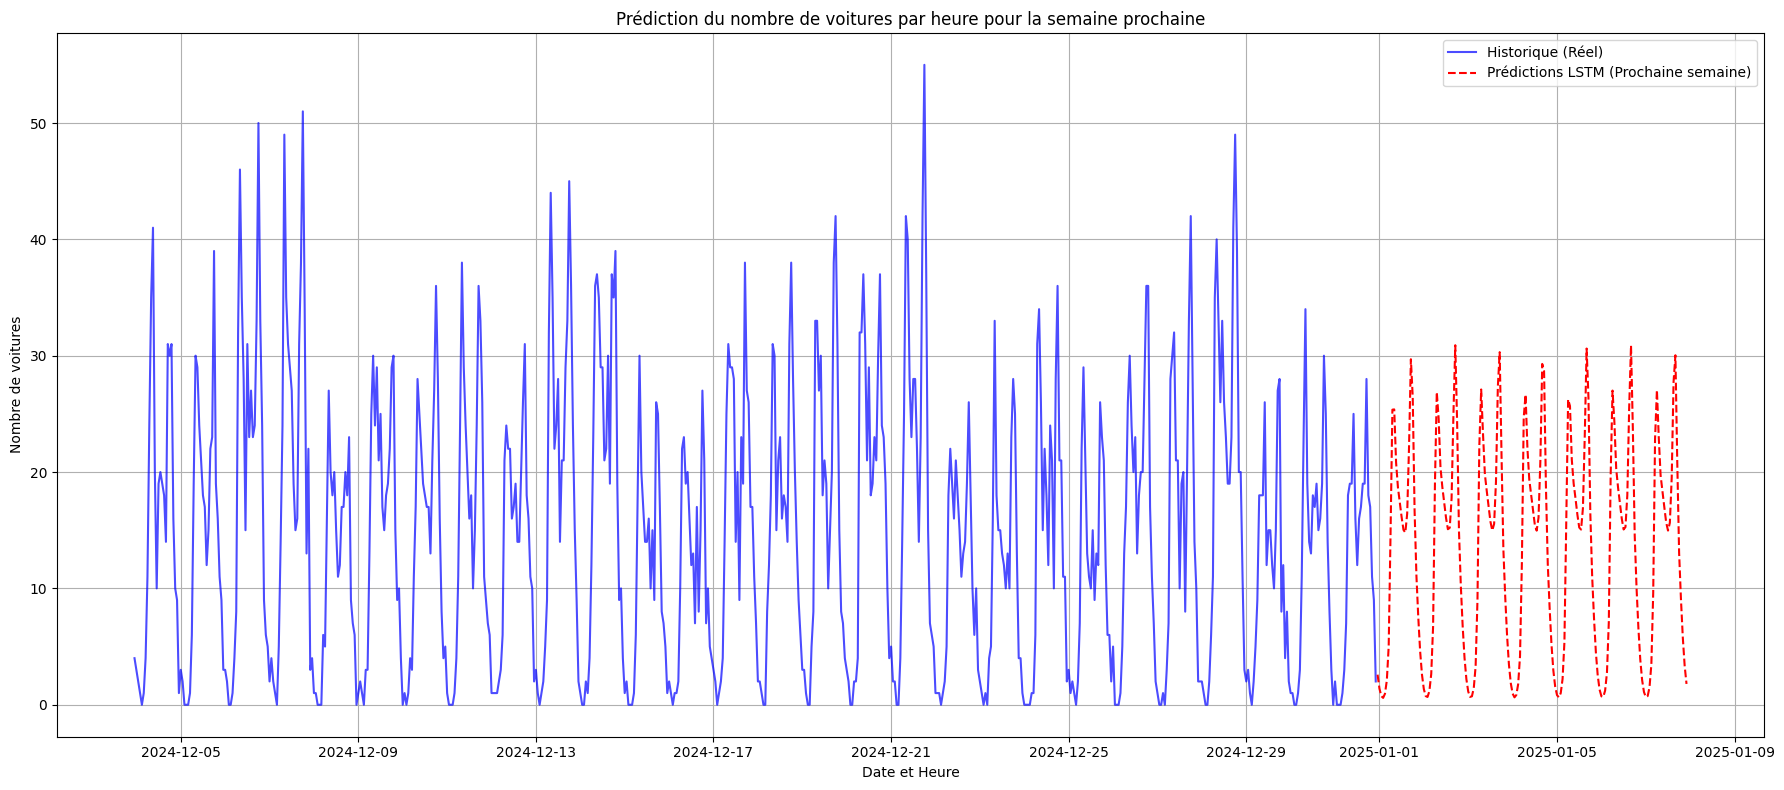

Aperçu des prédictions pour la semaine prochaine :
                     Prédiction_Voitures
2024-12-31 23:00:00             2.583985
2025-01-01 00:00:00             1.393157
2025-01-01 01:00:00             0.741694
2025-01-01 02:00:00             0.588562
2025-01-01 03:00:00             0.949963
                     Prédiction_Voitures
2025-01-07 18:00:00            13.059629
2025-01-07 19:00:00             9.059003
2025-01-07 20:00:00             5.771314
2025-01-07 21:00:00             3.350597
2025-01-07 22:00:00             1.787949


In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# It's crucial to redefine the model class exactly as it was defined
# when the model was saved. We'll grab the definition from the previous cell.
class LSTMModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# --- 1. Load the Model ---
model = LSTMModel() # Instantiate the model with the same architecture
model.load_state_dict(torch.load("lstm_voitures_par_heure_simplifie.pth"))
model.eval() # Set the model to evaluation mode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("✅ Modèle LSTM chargé avec succès.")

# --- 2. Préparer les données pour la prédiction ---
# Nous avons besoin des dernières 'lookback' observations pour initialiser la prédiction.
# 'scaled_data', 'lookback', 'scaler' et 'hourly' sont disponibles depuis la cellule précédente.

# Assurez-vous que 'scaled_data' est disponible (exécutée dans la cellule précédente)
if 'scaled_data' not in globals() or 'lookback' not in globals() or 'scaler' not in globals() or 'hourly' not in globals():
    print("Erreur : Les variables 'scaled_data', 'lookback', 'scaler' ou 'hourly' ne sont pas définies. Veuillez exécuter la cellule d'entraînement complète d'abord.")
else:
    # Prendre les 'lookback' dernières observations comme séquence d'entrée
    last_sequence = scaled_data[-lookback:]

    # Convertir en tenseur PyTorch et ajouter une dimension de batch
    input_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)

    # --- 3. Générer les prédictions pour la semaine prochaine (168 heures) ---
    future_predictions_scaled = []
    num_future_steps = 168 # 7 jours * 24 heures

    print(f"Génération des prédictions pour les {num_future_steps} prochaines heures...")

    with torch.no_grad():
        for _ in range(num_future_steps):
            predicted_value = model(input_sequence)
            future_predictions_scaled.append(predicted_value.item())

            # Mettre à jour la séquence d'entrée pour la prochaine prédiction
            # Enlever la plus ancienne observation et ajouter la nouvelle prédiction
            # predicted_value has shape (1, 1). We want (1, 1, 1) to concatenate along dim=1.
            predicted_value_tensor = predicted_value.unsqueeze(-1) # Correctly reshape to (1, 1, 1)
            input_sequence = torch.cat((input_sequence[:, 1:, :], predicted_value_tensor), dim=1)

    # --- 4. Inverse-transformer les prédictions ---
    future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

    print(f"✅ Prédictions générées : {len(future_predictions)} points.")

    # --- 5. Préparer l'index temporel pour les prédictions ---
    last_timestamp = hourly.index[-1]
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=num_future_steps, freq='H')

    # --- 6. Visualiser les prédictions ---
    plt.figure(figsize=(18, 8))

    # Plot les données historiques récentes (par exemple, les 4 dernières semaines)
    historical_plot_points = 4 * 7 * 24 # 4 semaines d'heures
    plt.plot(hourly.index[-historical_plot_points:], hourly['nombre_voitures'].tail(historical_plot_points),
             label="Historique (Réel)", color='blue', alpha=0.7)

    # Plot les prédictions
    plt.plot(future_dates, future_predictions, label="Prédictions LSTM (Prochaine semaine)", color='red', linestyle='--')

    plt.title("Prédiction du nombre de voitures par heure pour la semaine prochaine")
    plt.xlabel("Date et Heure")
    plt.ylabel("Nombre de voitures")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Aperçu des prédictions pour la semaine prochaine :")
    future_df = pd.DataFrame(future_predictions, index=future_dates, columns=['Prédiction_Voitures'])
    print(future_df.head())
    print(future_df.tail())